## this is part two , talks about modern workflow 

# check part 1 

https://github.com/ujjwal-basnet/Fine-Tuning-LLM/blob/main/formating_dataset.ipynb

In [2]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

from datasets import load_dataset

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

from trl import SFTConfig, SFTTrainer

/home/ujjwal/projects/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# setp 1  Configure 4-bit Quantization (QLoRA) 

QLoRA allows large models to be fine-tuned on limited GPU memory by loading weights in 4-bit NF4 quantization.

In [3]:
supported= torch.cuda.is_bf16_supported()
compute_dtype= torch.bfloat16 if supported else torch.float32

bnb_config = BitsAndBytesConfig(
    load_in_4bit= True, 
    bnb_4bit_quant_type= "nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype) # This controls the precision used during forward/backward computation



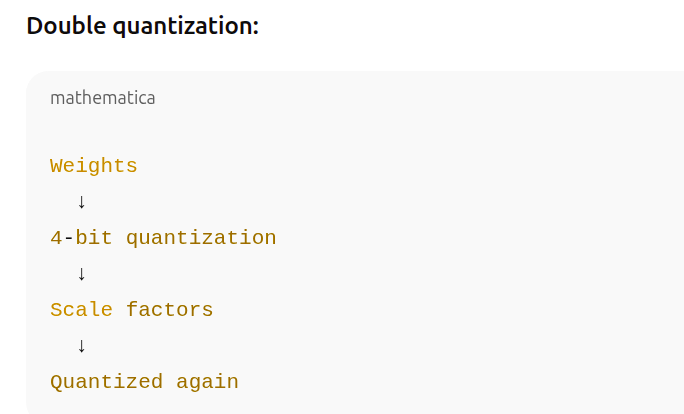

# load Base Model 

Prepare Model for k-bit Training

In [ ]:
repo_id = "microsoft/phi-3-mini-4k-instruct"
tokenizer_phi: SentencePieceBackend | TokenizersBackend | None= AutoTokenizer.from_pretrained(repo_id)
print(tokenizer_phi.chat_template)

{% for message in messages %}{% if message['role'] == 'system' %}{{'<|system|>
' + message['content'] + '<|end|>
'}}{% elif message['role'] == 'user' %}{{'<|user|>
' + message['content'] + '<|end|>
'}}{% elif message['role'] == 'assistant' %}{{'<|assistant|>
' + message['content'] + '<|end|>
'}}{% endif %}{% endfor %}{% if add_generation_prompt %}{{ '<|assistant|>
' }}{% else %}{{ eos_token }}{% endif %}


In [ ]:
model_id = "microsoft/phi-3-mini-4k-instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=bnb_config,
    dtype=compute_dtype
)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

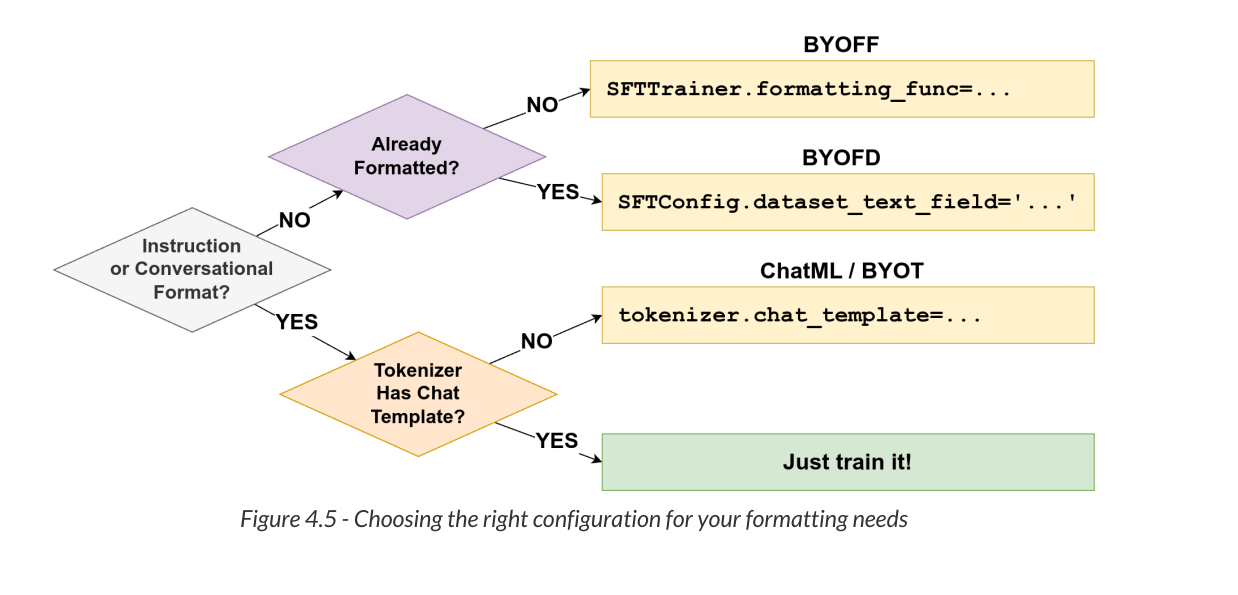